In [1]:
%matplotlib inline

## 偏流の可視化
### AIS　AISデータからの偏流予測データ
### JCOPE eas real-time analyses
### JCOPE nedo  reanalysis 

In [8]:
# 初期実行
import os
import pandas as pd
import filterpy.kalman as kf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from numpy.random import randn
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [ ]:
set([1,2,3,4])
for i in 

ais data shape: (900, 991)
jcope eas N shape: (1081, 1191)
jcope nedo N shape: (865, 831)
jcope eas E shape: (1081, 1191)
jcope nedo E shape: (865, 831)


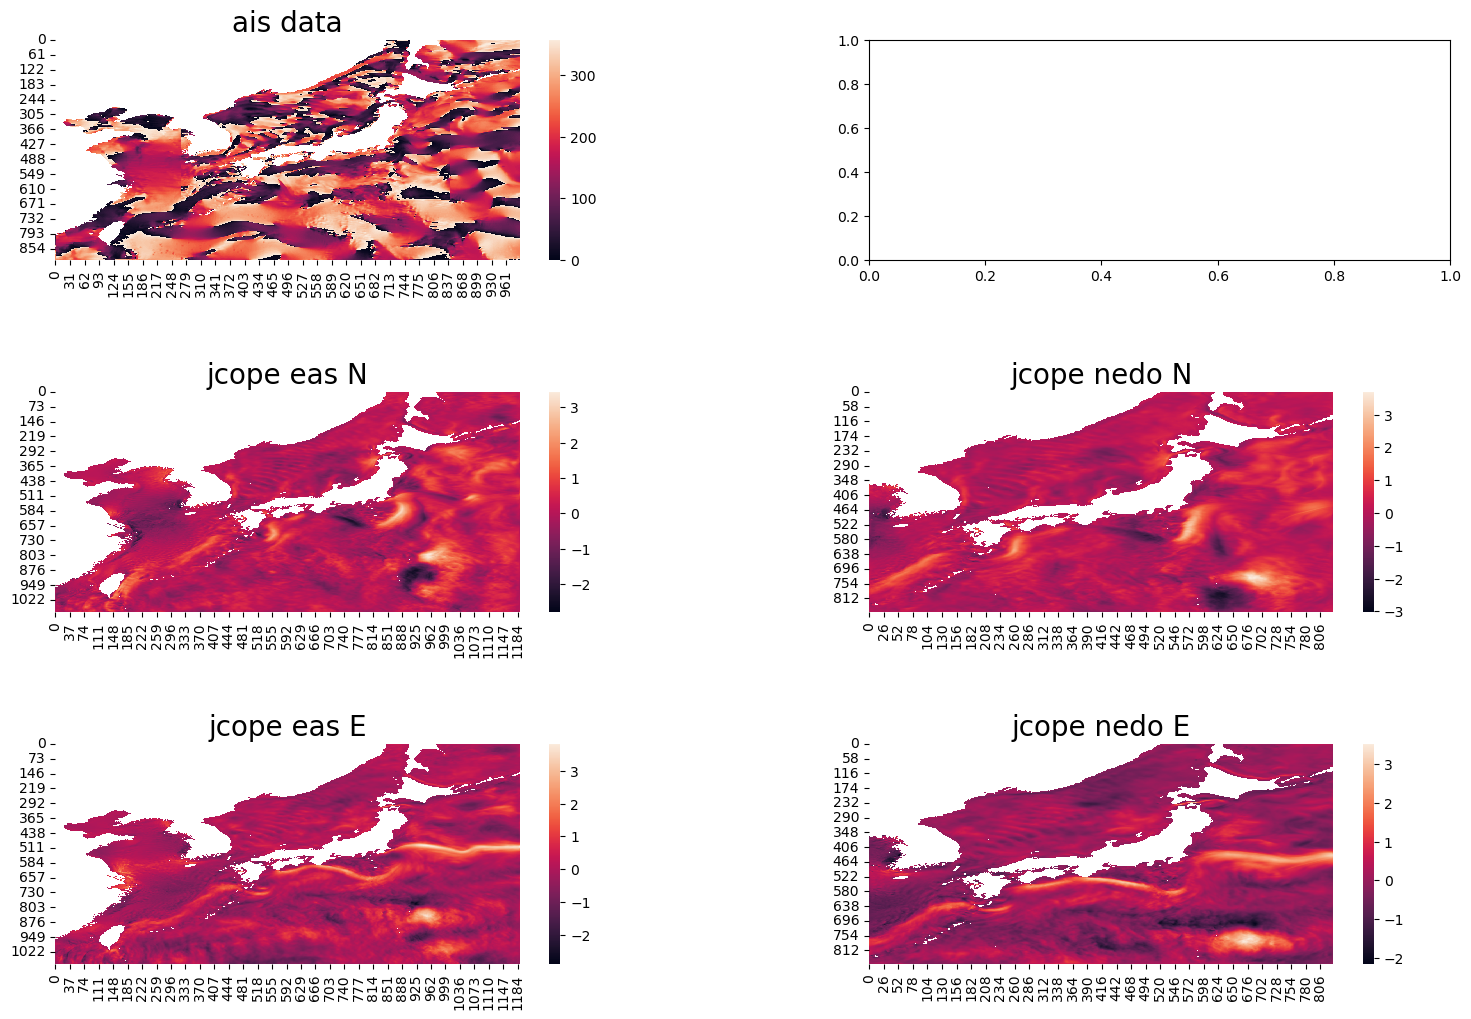

In [4]:


# ASI dataの読み込み
dt = "./data/201509190000"
ais_est_path = dt+"/ais_est/Cur.csv"
jcope_eas_N_path = dt+"/eas/N.csv"
jcope_nedo_N_path = dt+"/nedo/N.csv"
jcope_eas_E_path = dt+"/eas/E.csv"
jcope_nedo_E_path = dt+"/nedo/E.csv"
data_names = ['cur', 'jcope eas N', 'jcope nedo N', 'jcope eas E', 'jcope nedo E']
path = [ais_est_path, jcope_eas_N_path, jcope_nedo_N_path, jcope_eas_E_path, jcope_nedo_E_path]


datas = []
for p in path:
    datas.append(pd.read_csv(p, encoding="cp932",))

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [1, 0], [1, 1], [2, 0], [2, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]} shape: {data.values.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

jcope eas N shape: (1081, 1191)
jcope eas E shape: (1081, 1191)


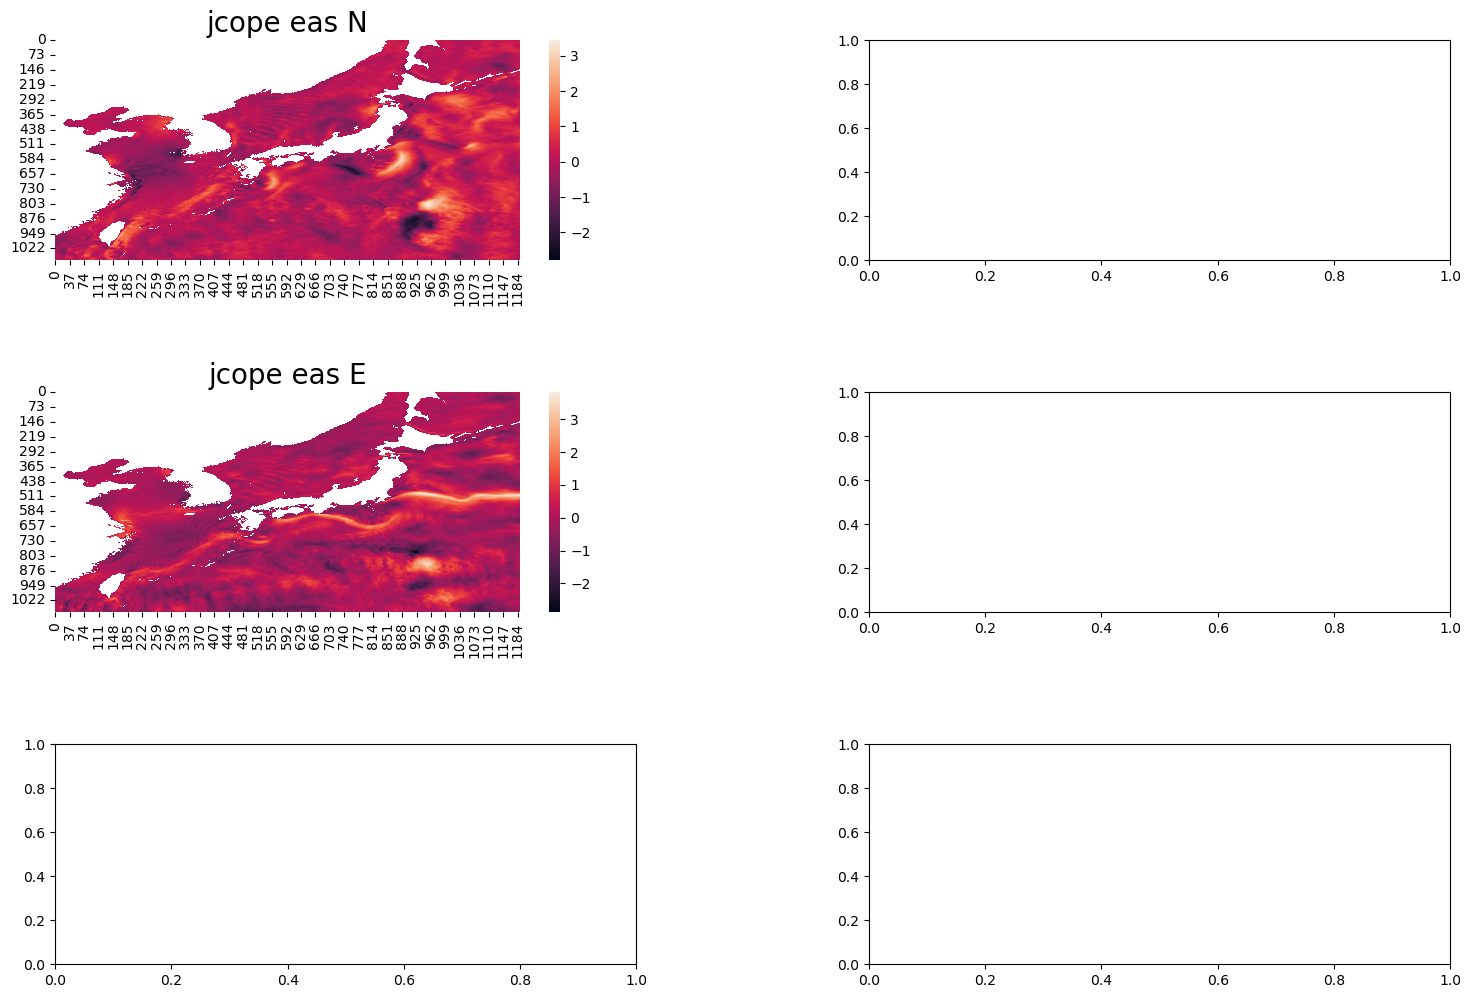

In [18]:
###### ASI dataの読み込み
dt = "./data/test"
jcope_eas_N_path = dt+"/N.csv"
jcope_eas_E_path = dt+"/E.csv"
data_names = ['jcope eas N', 'jcope eas E']
path = [jcope_eas_N_path, jcope_eas_E_path]


datas = []
for p in path:
    datas.append(pd.read_csv(p, encoding="cp932",))

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [1, 0], [1, 1], [2, 0], [2, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]} shape: {data.values.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

日本が見えて正しく変換できそう，nedoだけ日本のサイズ違うから直す必要あり

nedo 12N shape: (865, 831)
nedo 12E shape: (865, 831)
nedo 23N shape: (865, 831)
nedo 23E shape: (865, 831)


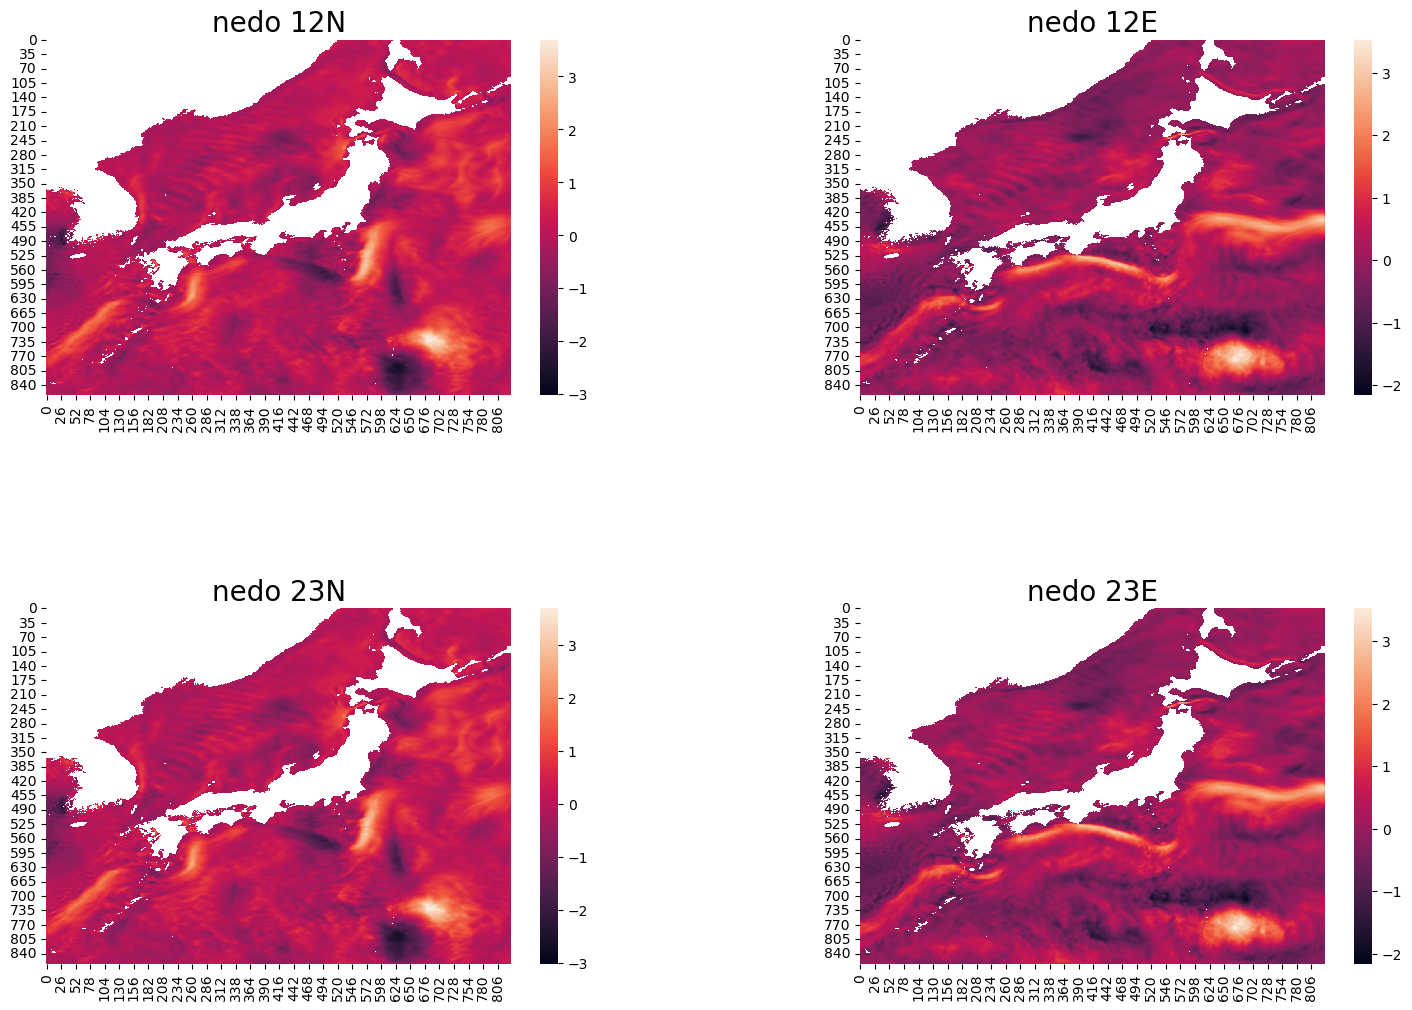

In [5]:
# ASI dataの読み込み
dt = "201509190012"
jcope_nedo_N_path = "./data/nedo/"+dt+"/N.csv"
jcope_nedo_E_path = "./data/nedo/"+dt+"/E.csv"
path = [jcope_nedo_N_path, jcope_nedo_E_path]
data_names = ["nedo 12N", "nedo 12E"]

datas = []
for p in path:
    datas.append(pd.read_csv(p, encoding="cp932",))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]} shape: {data.values.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])

dt = "201509190023"
jcope_nedo_N_path = "./data/nedo/"+dt+"/N.csv"
jcope_nedo_E_path = "./data/nedo/"+dt+"/E.csv"
path = [jcope_nedo_N_path, jcope_nedo_E_path]
data_names = [ "nedo 23N", "nedo 23E"]

datas = []
for p in path:
    datas.append(pd.read_csv(p, encoding="cp932",))

plot_place = [[1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]} shape: {data.values.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

なんか同じっぽい，時間によってこんな変わらないことってある？

2015 1/1 ais data 一日の変化を見たい

ais_E11 shape: (900, 991)
ais_N11 shape: (900, 991)
ais_E02 shape: (900, 991)
ais_N02 shape: (900, 991)


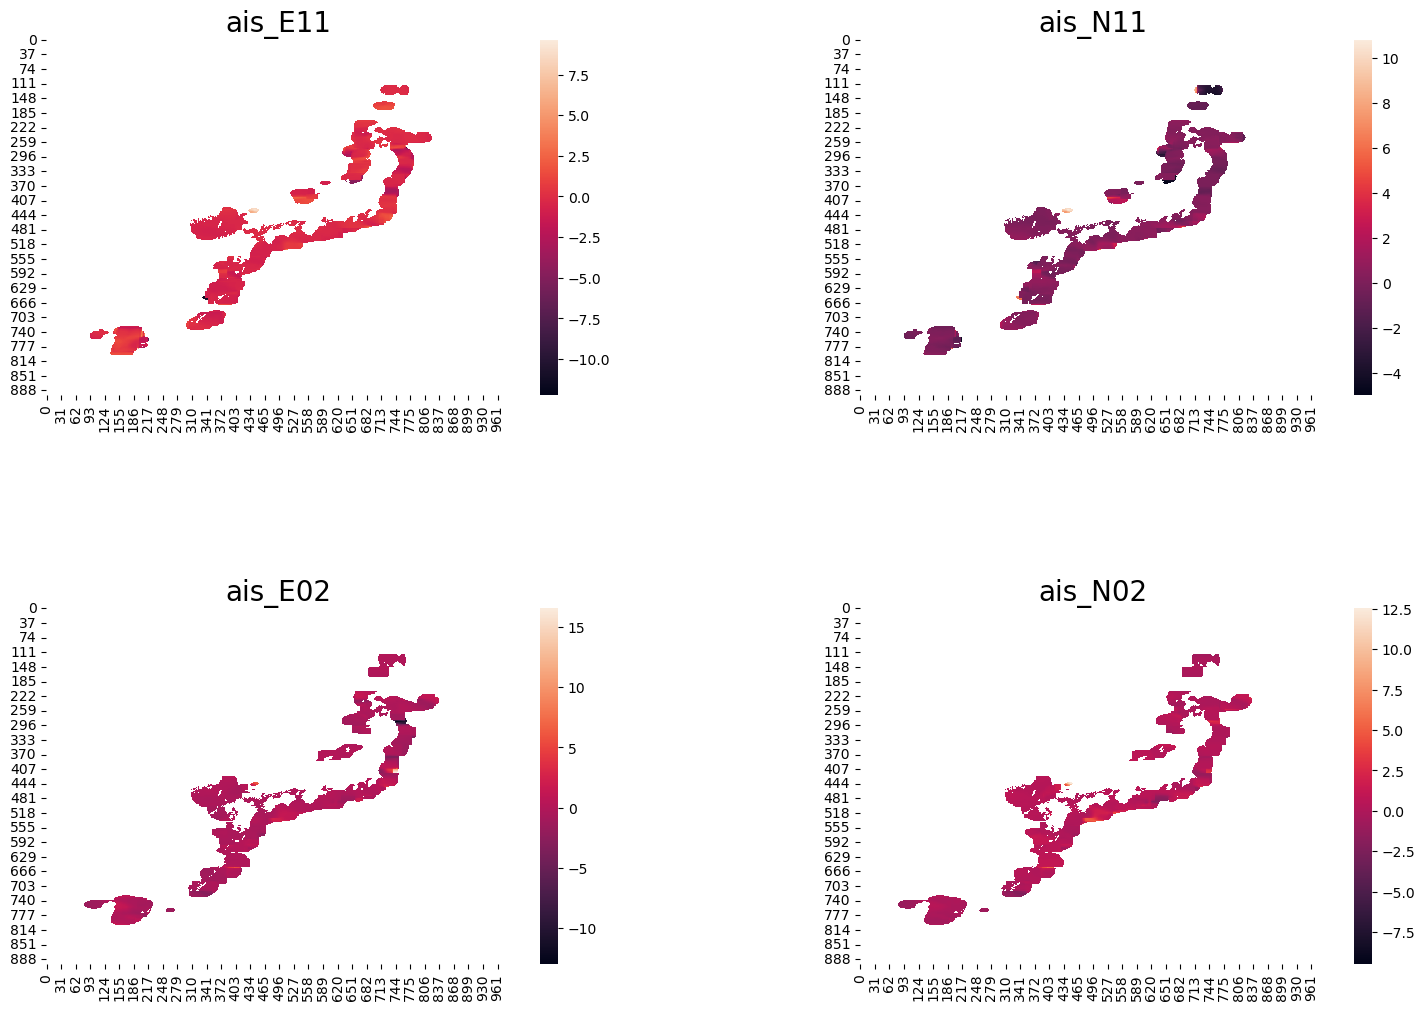

In [9]:
ais_N_path = "./data/ais/150101-1log/log/AisCurr2014123115N.csv"
ais_E_path = "./data/ais/150101-1log/log/AisCurr2014123115E.csv"
path = [ais_N_path, ais_E_path]
data_names = [ "ais_E11", "ais_N11"]

datas = []
for p in path:
    datas.append(pd.read_csv(p, encoding="cp932",))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]} shape: {data.values.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
    
ais_N_path = "./data/ais/150101-6log/log/AisCurr2015010102N.csv"
ais_E_path = "./data/ais/150101-6log/log/AisCurr2015010102E.csv"
path = [ais_N_path, ais_E_path]
data_names = [ "ais_E02", "ais_N02"]

datas = []
for p in path:
    datas.append(pd.read_csv(p, encoding="cp932",))

plot_place = [[1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]} shape: {data.values.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

信頼度が時間に応じて下がる様子

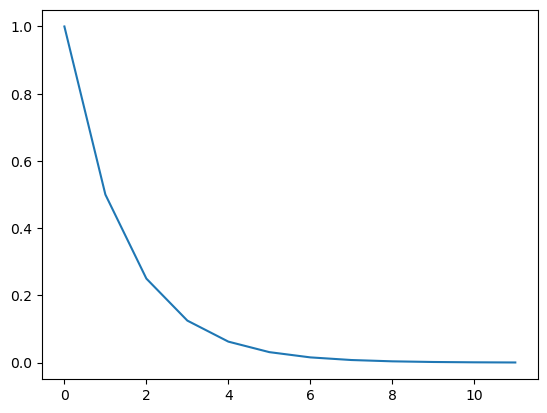

In [19]:
w_hr = [np.exp(-np.log(2)*(i/12)) for i in range(12) ]
plt.plot(np.arange(len(w_hr)), w_hr)

In [27]:
half = 0.1
permesh = 1.0
thres = 0.05
range_value = int(-half * np.log(thres)/(np.log(2)*permesh))
print(range_value)

0


In [17]:
p = "./data/ais/150101-1log/log/japan_20150101000000-20150101015959.ais4"
df = pd.read_csv(p, encoding="cp932",)
df['0.03333334']

Mmsi       DtIdx  LatIdx  LonIdx  ThetaDeg                            F
209225000  35055  1055    3889    141.000003063861    0.781272913728827
                          3890    174.933341289206    0.655856970005415
                          3891    175.060602222574     0.53654969770742
                          3892    175.199980438147    0.617511425917788
                                                            ...        
677052900  35056  744     3682    88.0000001521148    0.849757170744556
           35057  744     3682    88.1249832781548    0.880522963283416
                  745     3682    87.99999822024       1.02561995356497
                  746     3682    83.2631410221207    0.870410673358917
                  747     3682    263.607859076961    0.167954744650565
Name: 0.03333334, Length: 7693, dtype: object

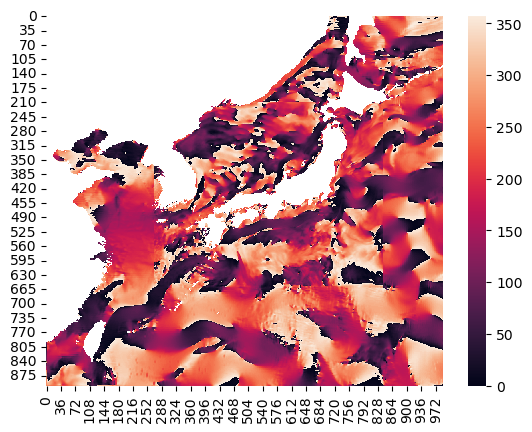

In [3]:
p =  "./data/ais/cur.csv"
data = pd.read_csv(p, encoding="cp932",)
sns.heatmap(data.values)
plt.show()

AIS N:(1050, 1191)
AIS E:(1050, 1191)
JCOPE N:(1081, 1191)
JCOPE E:(1081, 1191)


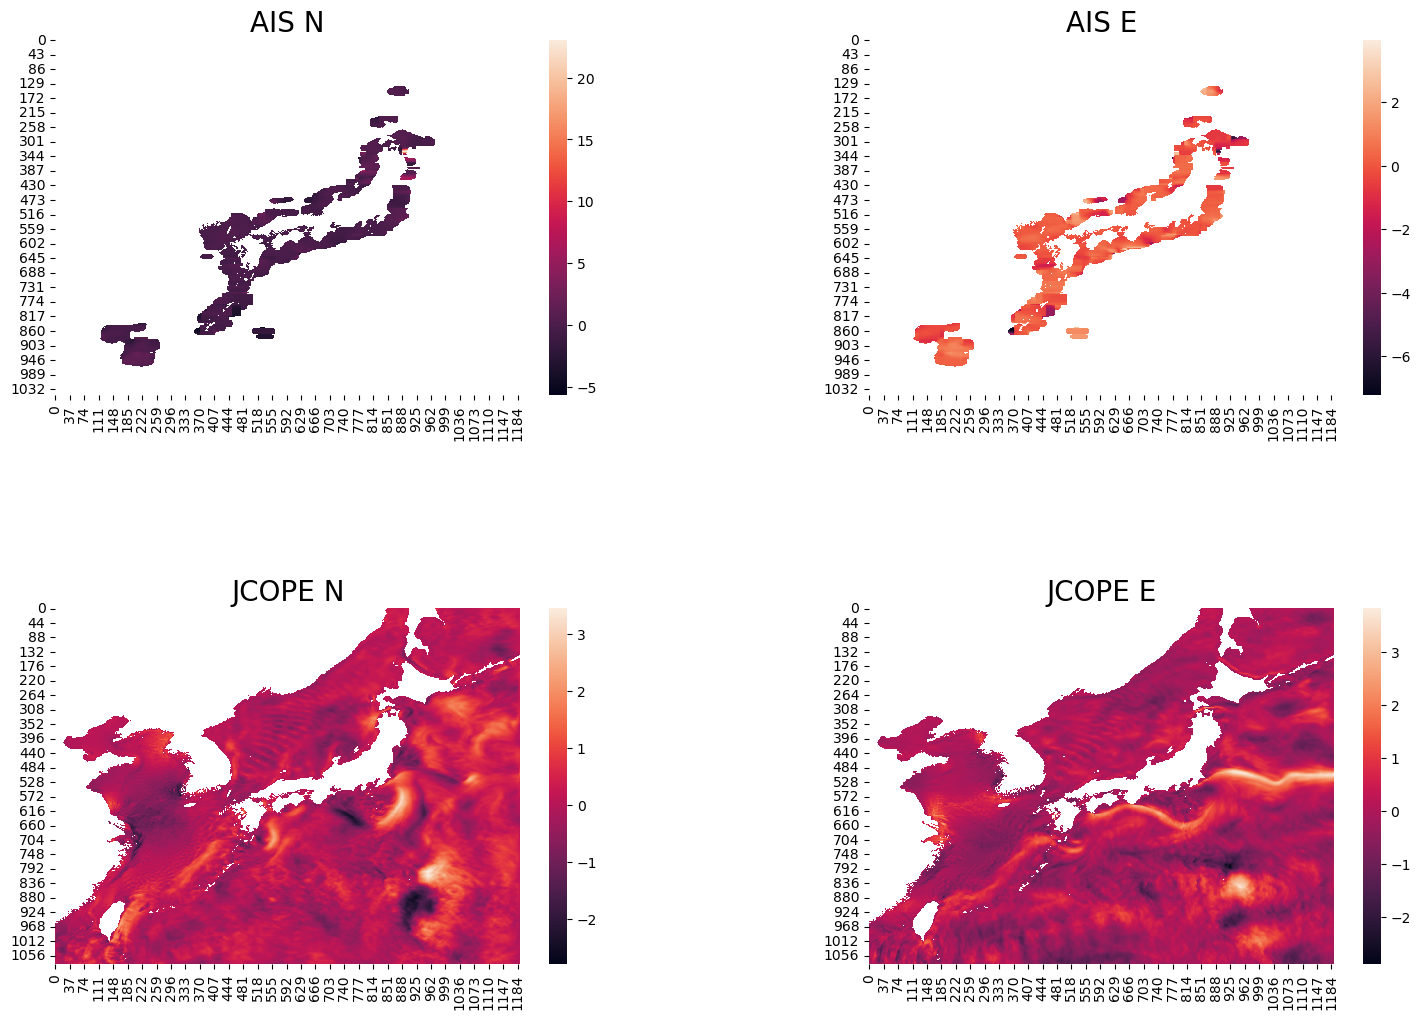

In [28]:
# pathの設定
path_ais = [ fr'./data/ais/20150919\150919-{i+1}log\log' for i in range(12)]
path_jcope = [fr'./data/eas\2015091900{i}' for i in range(24)]

# AIS (Mmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount)
ais = []
for i, p in enumerate(path_ais):
    ais2 = pd.read_csv(p+f"/japan_20150919{i*2:02}0000-20150919{i*2+1:02}5959.ais4", encoding="cp932", skiprows=[0])
    if i==0:
        ais = ais2
    else:
        ais = pd.concat([ais, ais2])

# AIS (MAP curN, curE)
date = [i for i in range(1817, 1824, 2)] + [i for i in range(1900, 1916, 2)]
ais_n_mapped = []
for i, p in enumerate(path_ais):
    ais_n_mapped.append(pd.read_csv(p+"/AisCurr201509"+str(date[i])+"N.csv", encoding="cp932",))
ais_e_mapped = []
for i, p in enumerate(path_ais):
    ais_e_mapped.append(pd.read_csv(p+"/AisCurr201509"+str(date[i])+"E.csv", encoding="cp932",))



AIS N:(1050, 1191)
AIS E:(1050, 1191)
JCOPE N:(1081, 1191)
JCOPE E:(1081, 1191)


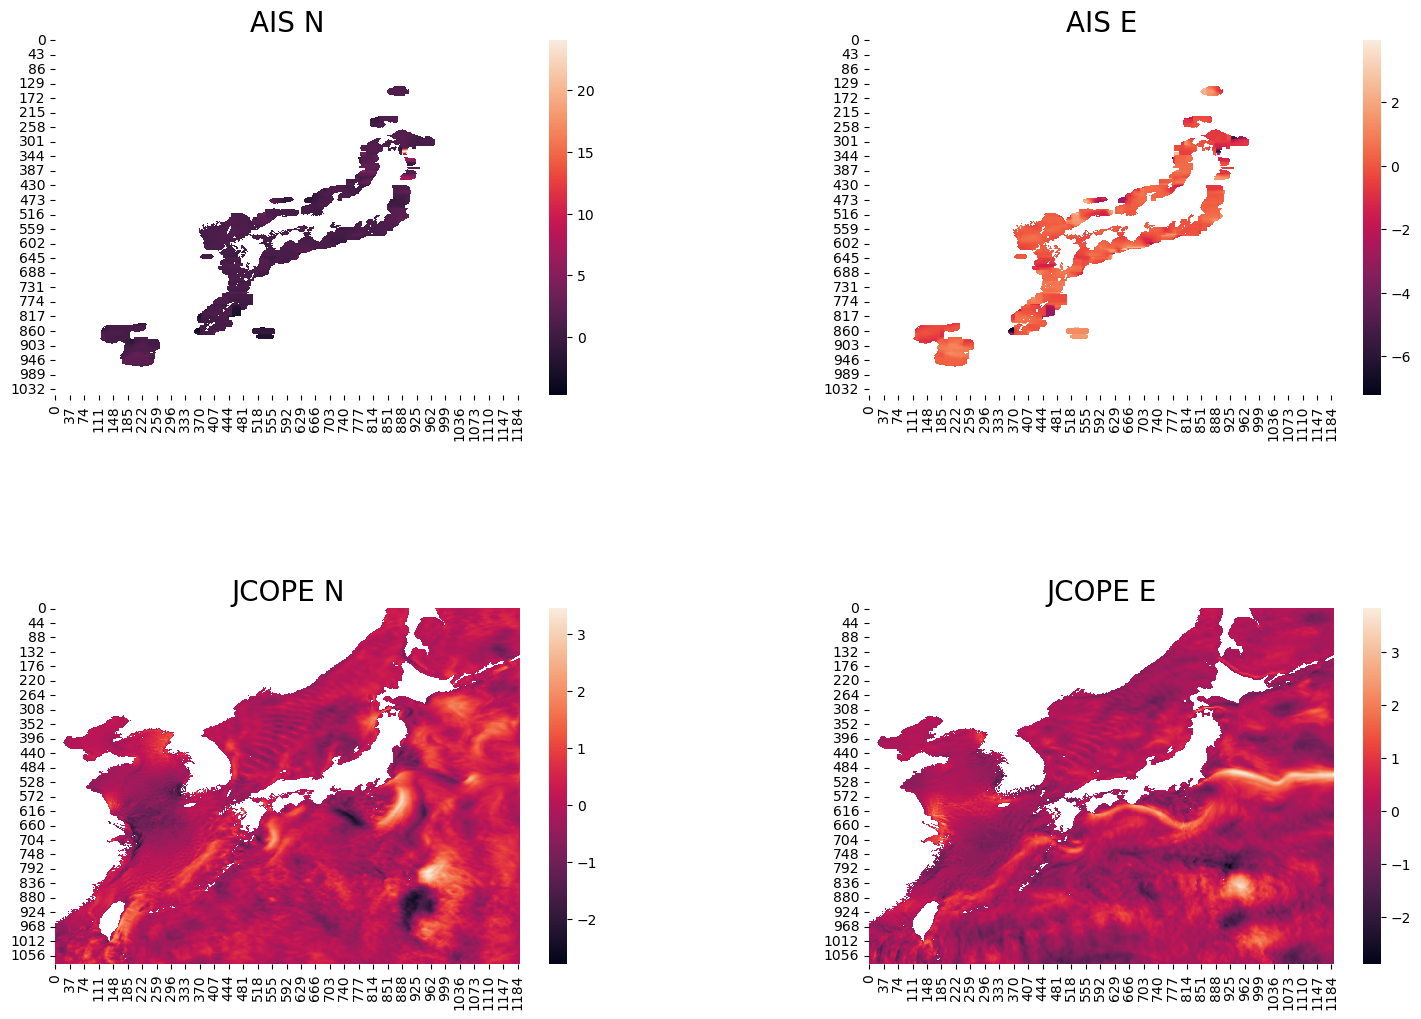

In [29]:
# JCOPE (MAP curN, curE)
jcope_n = []
for p in path_jcope:
    jcope_n.append(pd.read_csv(p+"/N.csv", encoding="cp932",))
jcope_e = []
for p in path_jcope:
    jcope_e.append(pd.read_csv(p+"/E.csv", encoding="cp932",))

datas = [ais_n_mapped[0], ais_e_mapped[0], jcope_n[0], jcope_e[0]]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()